# CSV

In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [19]:
directory = 'csvki'   
dfs = []
for filename in os.listdir(directory):
    path = f"{directory}/{filename}"
    if filename.endswith(".csv"):
        df_add = pd.read_csv(path, index_col=0)
        dfs.append(df_add)

df = pd.concat(dfs, ignore_index=True)
df.head()

,station_id,date,flow,flow_log,chunk_id,id_in_chunk
0,152170020,2015-08-10,0.09,0.086178,0,343
1,153220270,2015-09-10,4.68,1.736951,2,458
2,153190180,2015-08-10,0.22,0.198851,3,318
3,153190180,2015-08-17,0.22,0.198851,3,317
4,150190310,2015-11-25,1.12,0.751416,1,364


In [20]:
print(df.shape)
df.info()

(51614, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51614 entries, 0 to 51613
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   station_id   51614 non-null  int64  
 1   date         51614 non-null  object 
 2   flow         51614 non-null  float64
 3   flow_log     51614 non-null  float64
 4   chunk_id     51614 non-null  int64  
 5   id_in_chunk  51614 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 2.4+ MB


In [21]:
report = pd.DataFrame({
    "dtype": df.dtypes,
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean() * 100,
    "unique": df.nunique()
})

report

,dtype,missing,missing_%,unique
station_id,int64,0,0.0,713
date,object,0,0.0,804
flow,float64,0,0.0,2707
flow_log,float64,0,0.0,2707
chunk_id,int64,0,0.0,221
id_in_chunk,int64,0,0.0,500


In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
min(df['date'])

'2015-07-04'

In [24]:
max(df['date'])

'2024-11-30'

In [25]:
df['flow'].describe()

count    51614.000000
mean        30.869046
std        136.077420
min          0.000000
25%          0.720000
50%          2.280000
75%          8.727500
max       3280.000000
Name: flow, dtype: float64

In [26]:
df.drop(columns=['station_id', 'flow_log'], inplace=True)
df.head()

,date,flow,chunk_id,id_in_chunk
0,2015-08-10,0.09,0,343
1,2015-09-10,4.68,2,458
2,2015-08-10,0.22,3,318
3,2015-08-17,0.22,3,317
4,2015-11-25,1.12,1,364


In [27]:
# Cleaning null data
null_values = []

for idx in range(len(df)):
    row = df.iloc[idx]
    chunk = np.load(f'images/images_chunk_{int(row["chunk_id"]):03d}.npy', mmap_mode='r')
    image = chunk[int(row['id_in_chunk'])]
    if np.isnan(image).any():
        null_values.append(idx)

print(f"Images with NaN: {len(null_values)} / {len(df)}")

Images with NaN: 102 / 51614


In [28]:
df = df.drop(index = null_values).reset_index(drop=True)

In [29]:
final_csv = df.to_csv('df_final.csv', index=False)

# IMAGES

In [30]:
path = 'images'
number_files= len([
    file for file in os.listdir(path)
    if file.endswith(".npy")
])

print(number_files)

221


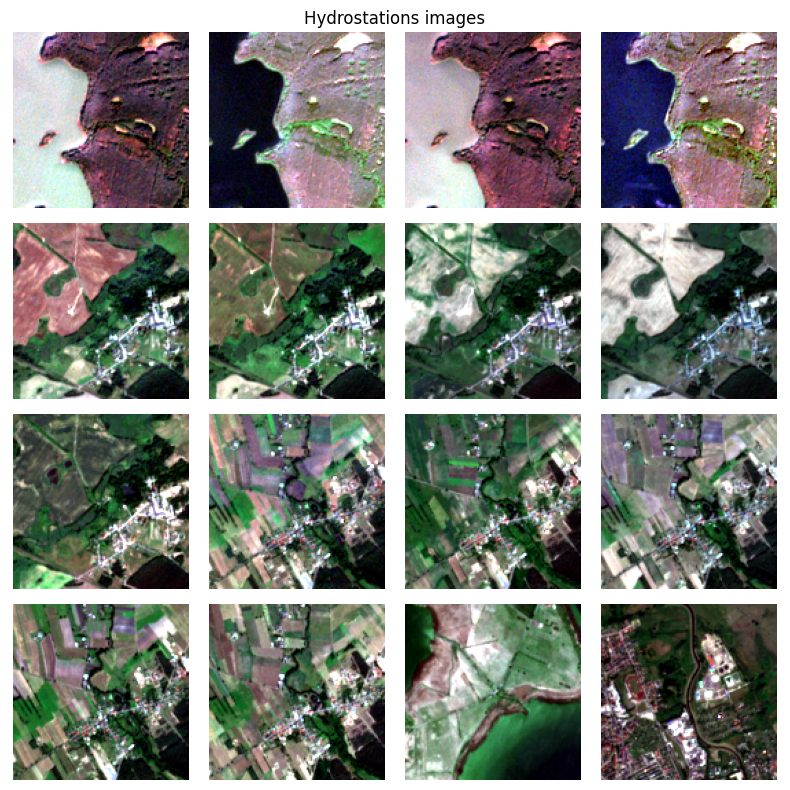

In [31]:
bands=[1,2,3]
cols= 4
rows = 4
num_images = rows*cols

plt.figure(figsize=(2 * cols, 2 * rows))
plt.title('Hydrostations images')
plt.axis('off')

images = np.load(f"images/images_chunk_001.npy")
for i in range(num_images):
    if  i >= len(images):
            break

    img = images[i]
    img = img[:, :, bands].astype('float32')
    img /= img.max() if img.max() > 0 else 1

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()
